In [24]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [5]:
# --- CONFIGURATION ---
WARDS_FILE = "~/Downloads/URBAN-INEQUALITY-IN-BARODA/data/interim/vadodara_project.gpkg"
ENV_FILE = "~/Downloads/URBAN-INEQUALITY-IN-BARODA/data/processed/ward_indicators.csv"
ACCESS_FILE = "~/Downloads/URBAN-INEQUALITY-IN-BARODA/data/processed/ward_travel_times.csv"

In [6]:
# Set visual style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)

In [7]:
# 1. LOAD DATA
print("-> Loading Data Layers...")
wards = gpd.read_file(WARDS_FILE)
env_data = pd.read_csv(ENV_FILE)
access_data = pd.read_csv(ACCESS_FILE)

-> Loading Data Layers...


In [8]:
# 2. MERGE LAYERS
# We combine the Map + Crowding Data + Travel Time Data
final_df = wards.merge(env_data, on='ward_id').merge(access_data, on='ward_id')

In [9]:
# 3. CALCULATE "URBAN OPPORTUNITY INDEX"
# Methodology:
# - Normalize all columns to 0-1 range.
# - Invert "Negative" metrics (where High = Bad).

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

In [10]:
# A. Normalize Basic Columns
final_df['n_green'] = normalize(final_df['green_density'])         # High = Good
final_df['n_built'] = normalize(final_df['building_density'])      # High = Bad (Crowded)
final_df['n_hosp'] = normalize(final_df['hospitals_min'])          # High = Bad (Far)
final_df['n_school'] = normalize(final_df['schools_min'])          # High = Bad (Far)
final_df['n_trans'] = normalize(final_df['transport_min'])         # High = Bad (Far)

In [11]:
# B. Calculate Sub-Indices (Higher Score = Better Life)
# Environment Score: High Greenery + Low Crowding
final_df['Score_Env'] = (final_df['n_green'] + (1 - final_df['n_built'])) / 2

# Access Score: Short times to Hospital, School, Transport
final_df['Score_Access'] = ((1 - final_df['n_hosp']) + (1 - final_df['n_school']) + (1 - final_df['n_trans'])) / 3

In [12]:
# C. FINAL INDEX (The "Inequality Score")
final_df['Final_Index'] = (final_df['Score_Env'] + final_df['Score_Access']) / 2

print("-> Index Calculated. Summary:")
print(final_df[['ward_id', 'Final_Index', 'hospitals_min', 'green_density']].head())

-> Index Calculated. Summary:
   ward_id  Final_Index  hospitals_min  green_density
0        1     0.318435           6.01       0.000000
1        2     0.476004           0.29       0.652434
2        3     0.736150           1.38       0.765192
3        4     0.433142           7.54       0.002569
4        5     0.406764           7.18       0.000000


Text(0.5, 0.98, 'Urban Inequality in Vadodara: Multidimensional Analysis')

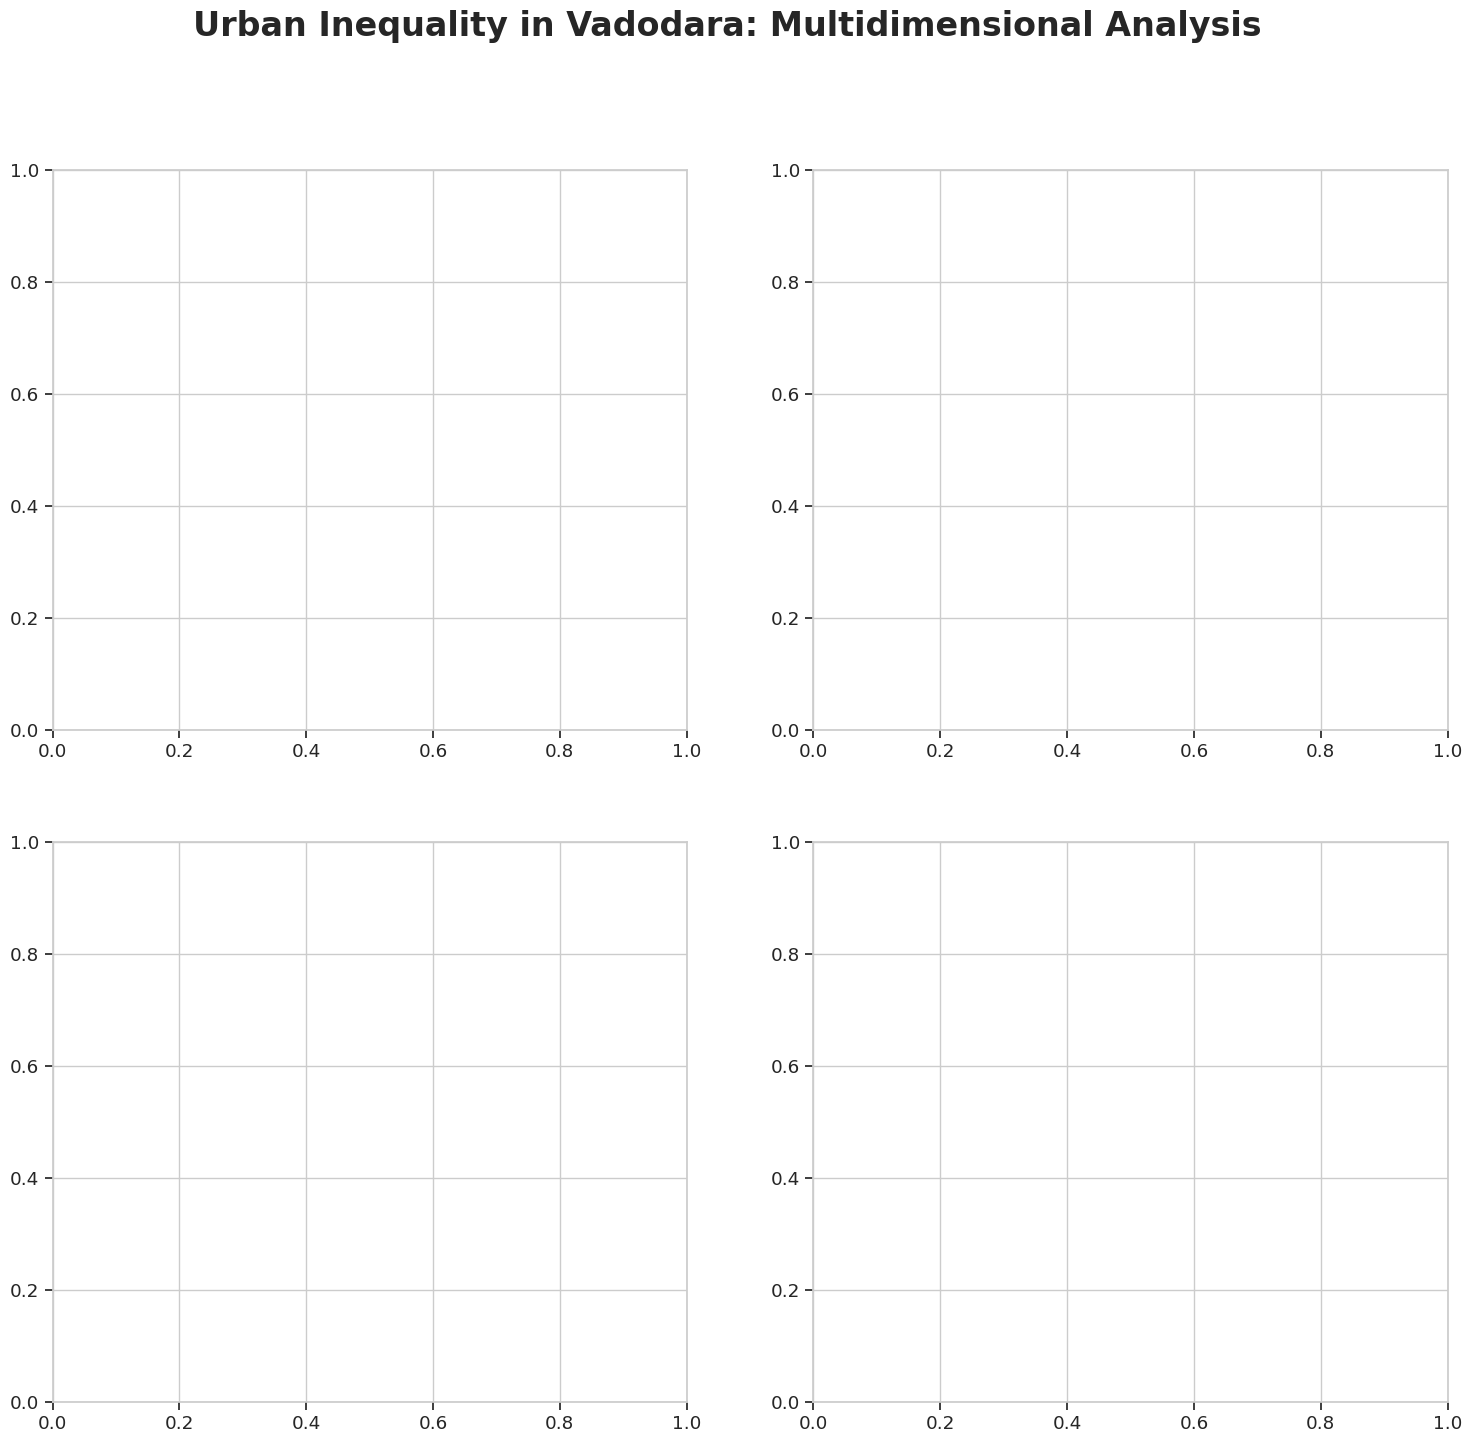

In [13]:
# 4. VISUALIZATION (The Dashboard)
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('Urban Inequality in Vadodara: Multidimensional Analysis', fontsize=24, weight='bold')

In [14]:
# Helper function for consistent mapping
def plot_map(ax, column, title, cmap, label):
    final_df.plot(column=column, cmap=cmap, linewidth=0.8, edgecolor='0.8', legend=True, ax=ax, legend_kwds={'label': label, 'orientation': "horizontal"})
    ax.set_title(title, fontsize=14, weight='bold')
    ax.axis('off')

In [15]:
# Map 1: The Master Index (Inequality)
# Light Yellow = High Opportunity, Dark Purple = Neglected
plot_map(axes[0, 0], 'Final_Index', 'Overall Urban Opportunity Index\n(Brighter = Better Quality of Life)', 'viridis', "Index Score (0-1)")

In [16]:
# Map 2: Medical Access
# Red/Dark = Far from Hospital
plot_map(axes[0, 1], 'hospitals_min', 'Medical Accessibility\n(Travel Time in Minutes)', 'Reds', "Minutes to Nearest Hospital")

In [17]:
# Map 3: Green Spaces
# Green = High Greenery
plot_map(axes[1, 0], 'green_density', 'Green Lung Cover\n(% of Ward Area)', 'Greens', "Percentage Green Space")

In [21]:
# Map 4: Transport Access
# Blue = Far from Transport
plot_map(axes[1, 1], 'transport_min', 'Public Transport Access\n(Travel Time in Minutes)', 'Blues', "Minutes to Bus/Train")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle

<Figure size 640x480 with 0 Axes>

In [ ]:
# Save to file
output_folder = os.path.expanduser("~/Downloads/URBAN-INEQUALITY-IN-BARODA/output/maps")
output_path = os.path.join(output_folder, "thesis_dashboard.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✅ SUCCESS: Dashboard saved to {output_path}")
plt.show()

In [ ]:
# DIAGNOSTIC STEP
print(f"Total Rows in Final DF: {len(final_df)}")
print("\n--- Check for Missing Values (NaN) ---")
print(final_df[['Final_Index', 'hospitals_min', 'green_density']].isna().sum())

print("\n--- Check Geometry ---")
print(final_df.geometry.head())
print(f"Is Geometry Valid? {final_df.geometry.is_valid.all()}")
print(f"Coordinate System: {final_df.crs}")

print("\n--- Sample Data ---")
print(final_df[['ward_id', 'Final_Index']].head())

In [36]:
# 1. Force Convert to Lat/Lon (GPS Coordinates)
# This fixes the "Zoom" issue by putting everything in standard degrees
plot_data = final_df.to_crs(epsg=4326)

Text(0.5, 0.96, 'Urban Inequality in Vadodara: Multidimensional Analysis')

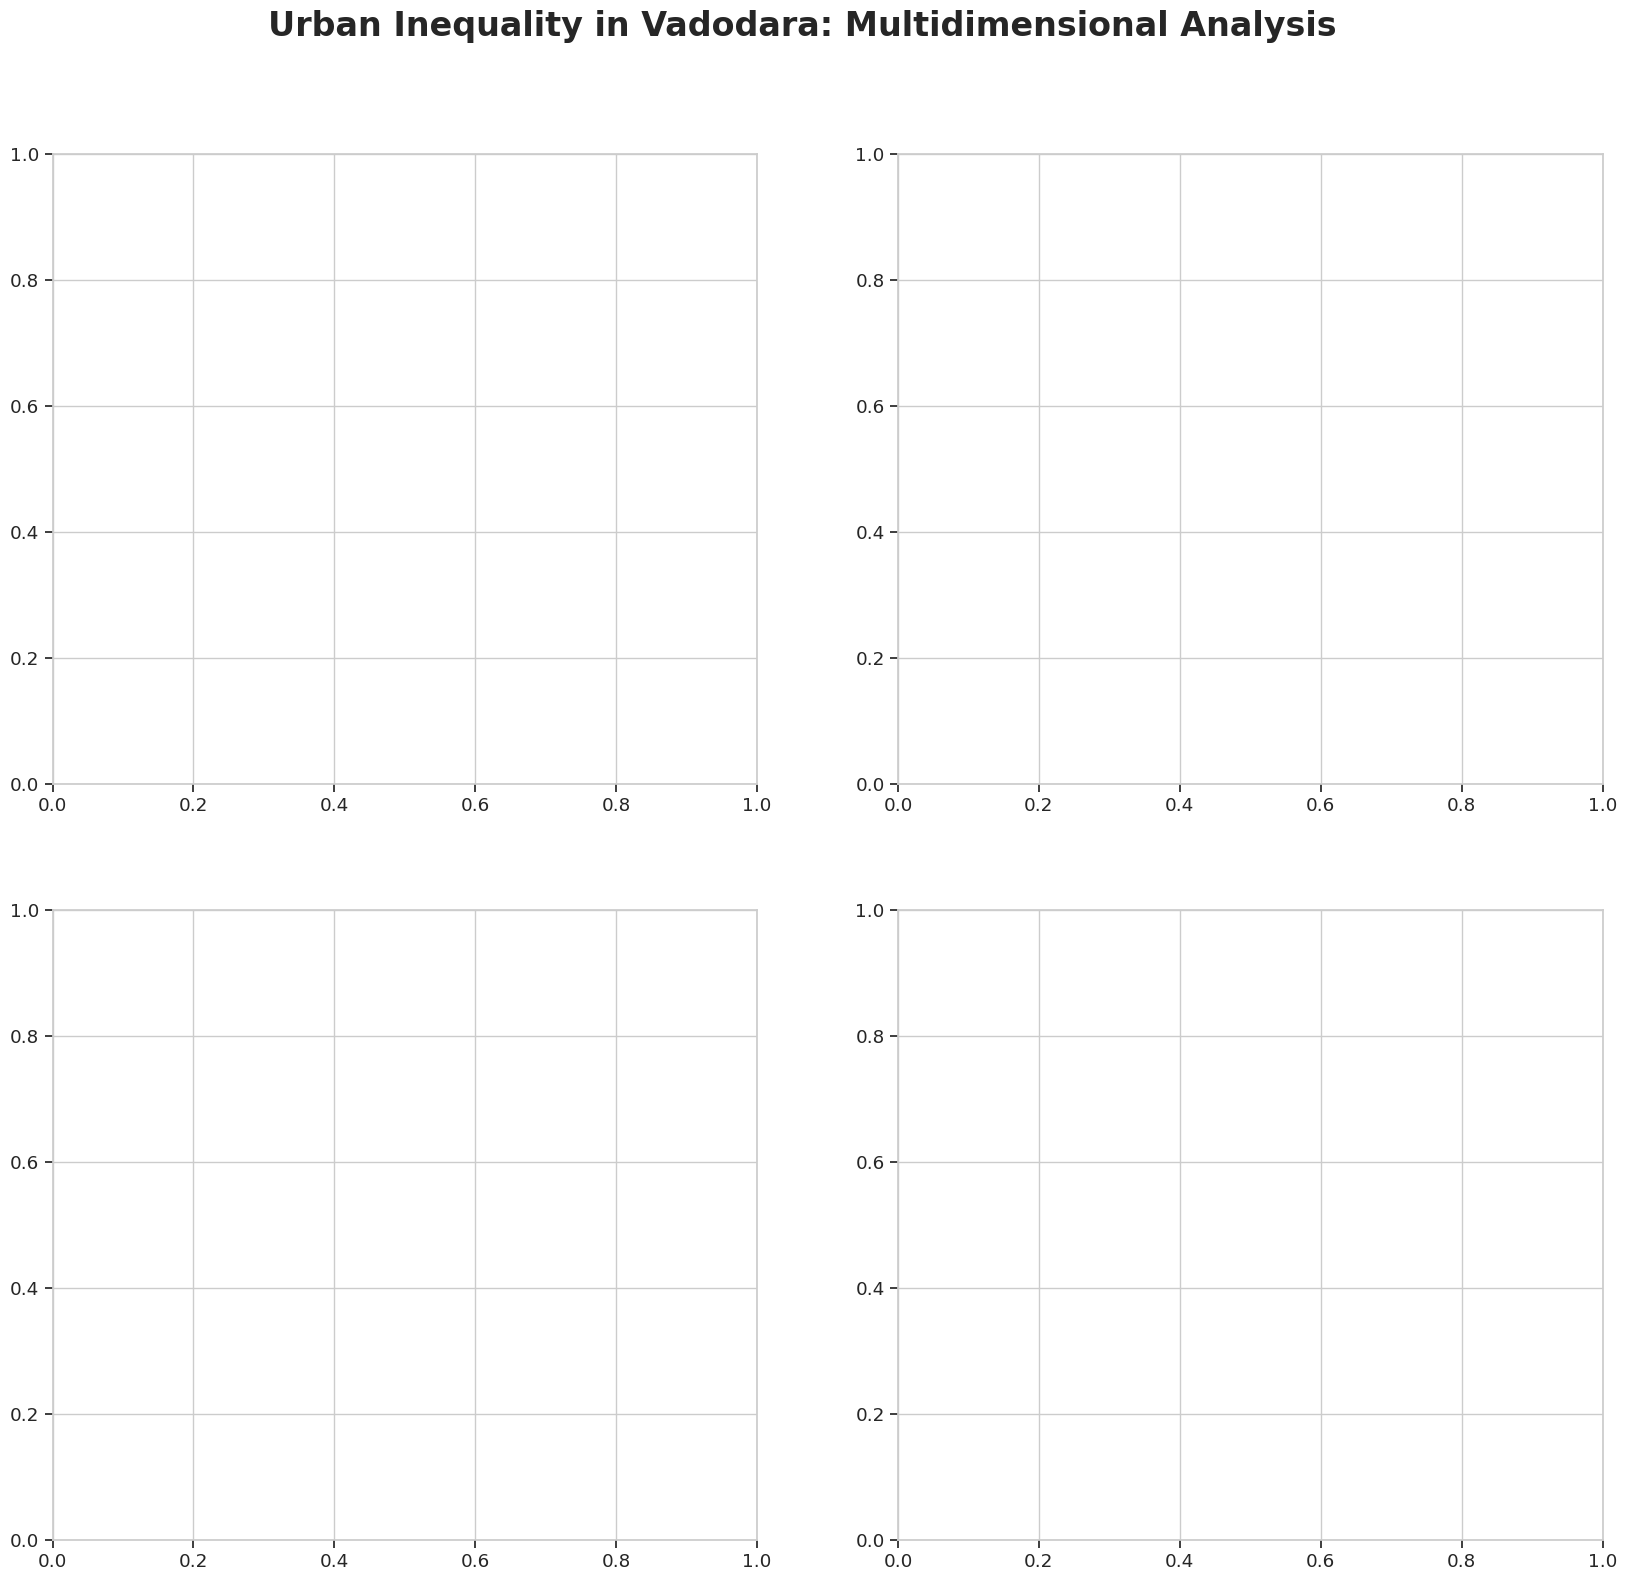

In [37]:
# 2. Setup the Canvas
fig, axes = plt.subplots(2, 2, figsize=(20, 18))
fig.suptitle('Urban Inequality in Vadodara: Multidimensional Analysis', fontsize=24, weight='bold', y=0.96)

In [38]:
# 3. Define the Plotting Function (Direct logic)
def plot_layer(ax, column, title, cmap, label):
    # Plot the base map
    plot_data.plot(column=column, 
                   cmap=cmap, 
                   linewidth=0.5, 
                   edgecolor='black', 
                   legend=True, 
                   ax=ax,
                   legend_kwds={'label': label, 'orientation': "horizontal", 'shrink': 0.8})
    
    # Force the camera to look at the city
    # We explicitly tell it to zoom to the data's boundaries
    minx, miny, maxx, maxy = plot_data.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    
    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_axis_off()

In [39]:
# 4. Draw the 4 Maps
print("-> Drawing Map 1: Inequality Index...")
plot_layer(axes[0, 0], 'Final_Index', 'Overall Urban Opportunity Index\n(Yellow = High Opportunity)', 'viridis', "Index Score")

print("-> Drawing Map 2: Hospitals...")
plot_layer(axes[0, 1], 'hospitals_min', 'Medical Accessibility\n(Travel Time)', 'Reds', "Minutes to Hospital")

print("-> Drawing Map 3: Greenery...")
plot_layer(axes[1, 0], 'green_density', 'Green Lung Cover\n(Vegetation)', 'Greens', "% Green Space")

print("-> Drawing Map 4: Transport...")
plot_layer(axes[1, 1], 'transport_min', 'Public Transport Access\n(Travel Time)', 'Blues', "Minutes to Transport")

-> Drawing Map 1: Inequality Index...
-> Drawing Map 2: Hospitals...
-> Drawing Map 3: Greenery...
-> Drawing Map 4: Transport...


In [40]:
# 5. Save explicitly using the 'fig' object
output_folder = os.path.expanduser("~/Downloads/URBAN-INEQUALITY-IN-BARODA/output/maps")
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, "thesis_dashboard_v2.png")

print("-> Saving...")
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ SUCCESS: Saved to {output_path}")

plt.show()

-> Saving...
✅ SUCCESS: Saved to /home/ethan/Downloads/URBAN-INEQUALITY-IN-BARODA/output/maps/thesis_dashboard_v2.png
